<a href="https://colab.research.google.com/github/fdac25/MP2/blob/main/Vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt



In [16]:
df = pd.read_csv("ggood3_project_summary.csv", sep=";")
df.columns = ['project','commit','author','time','message']
df['Month'] = pd.to_datetime(df['time'], unit='s').dt.strftime('%Y-%m')
df.head()

,project,commit,author,time,message,Month
0,vida-nyu_reprozip,001df9285761c6595f20aefb207446b96d48f80c,Remi Rampin <remirampin@gmail.com>,1476041829,GUI: Confirm exit if still set up\n,2016-10
1,vida-nyu_reprozip,00289bae9797b3f95c0960d3307cda461ce7d6f6,Remi Rampin <remirampin@gmail.com>,1449255763,DOC: Mention --pass-env and --set-env\n,2015-12
2,vida-nyu_reprozip,004c75dc60b0355499ca9f691ae9ba1232bfe318,Remi Rampin <remirampin@gmail.com>,1430939900,Updates copyright year to 2015\n,2015-05
3,vida-nyu_reprozip,00617b8d1192fb951c6606bf2c6f51b59f150341,Remi Rampin <remirampin@gmail.com>,1422299631,Moves SSH command running to vagrant.run_comma...,2015-01
4,vida-nyu_reprozip,0061e8c5de80cb5467caf5ad6be119be6f8533e0,Remi Rampin <remirampin@gmail.com>,1445875132,Merge branch 'conda-py3' into 'master'\n,2015-10


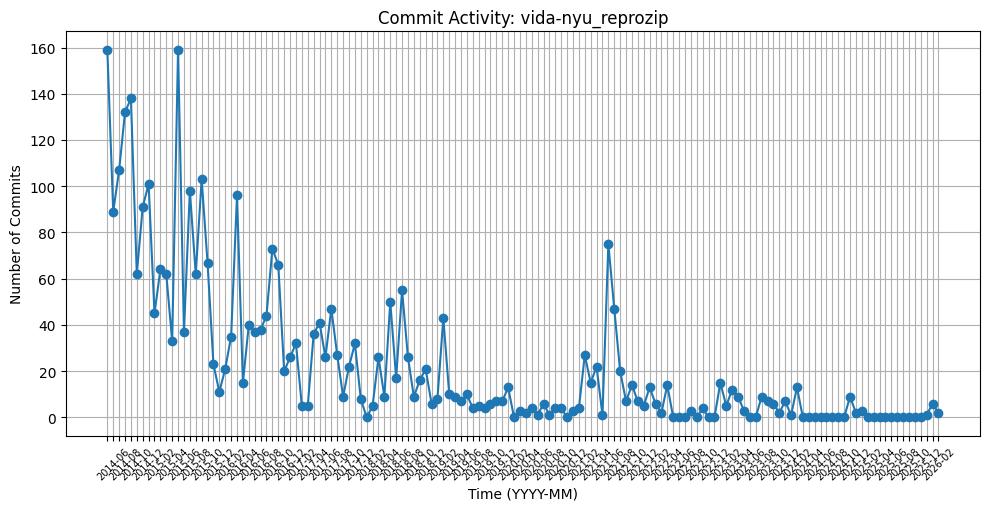

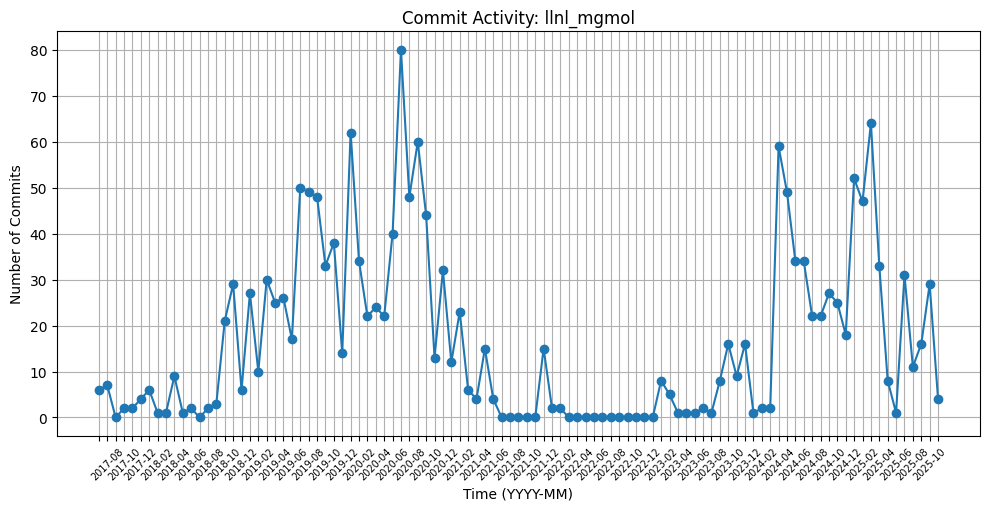

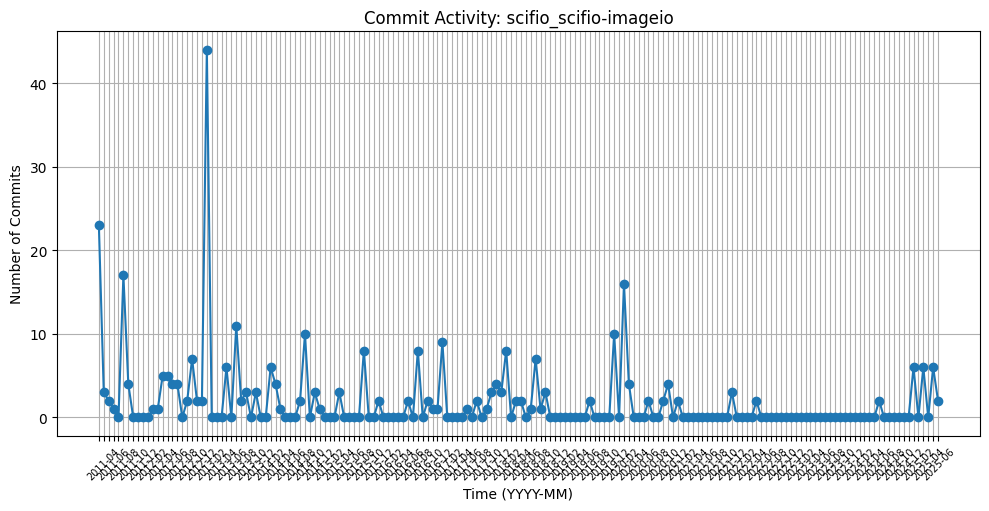

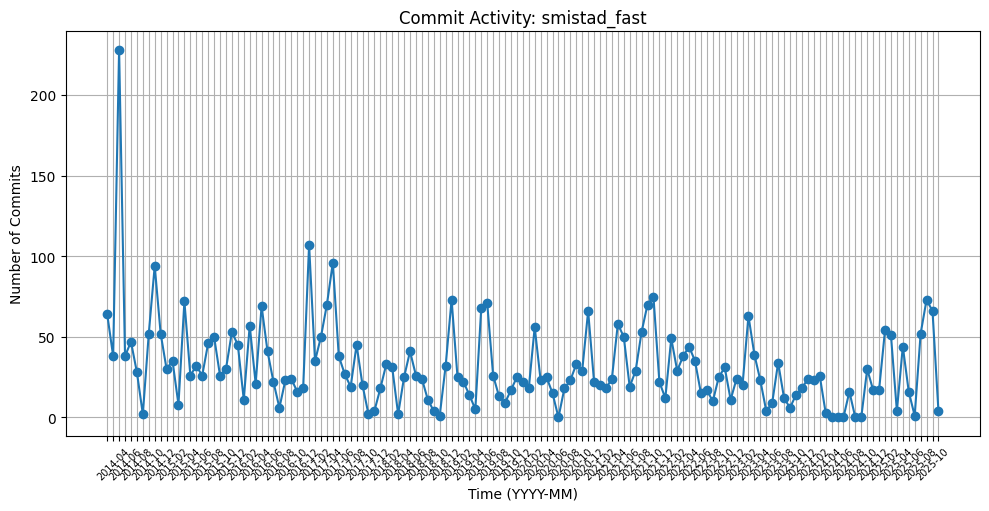

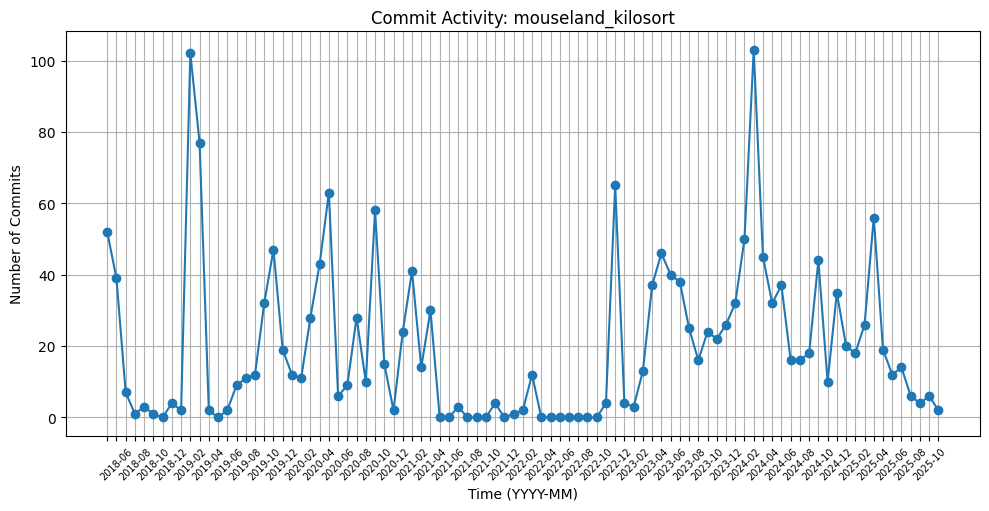

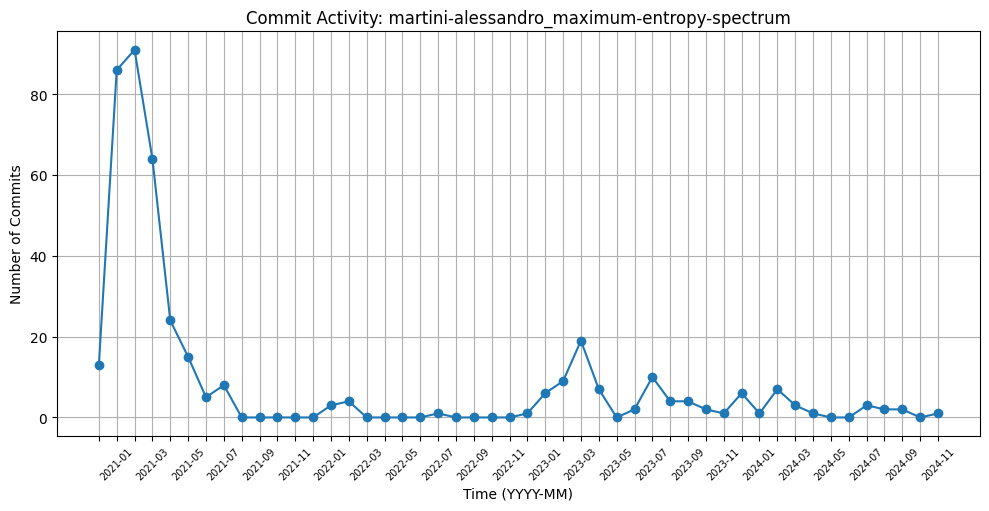

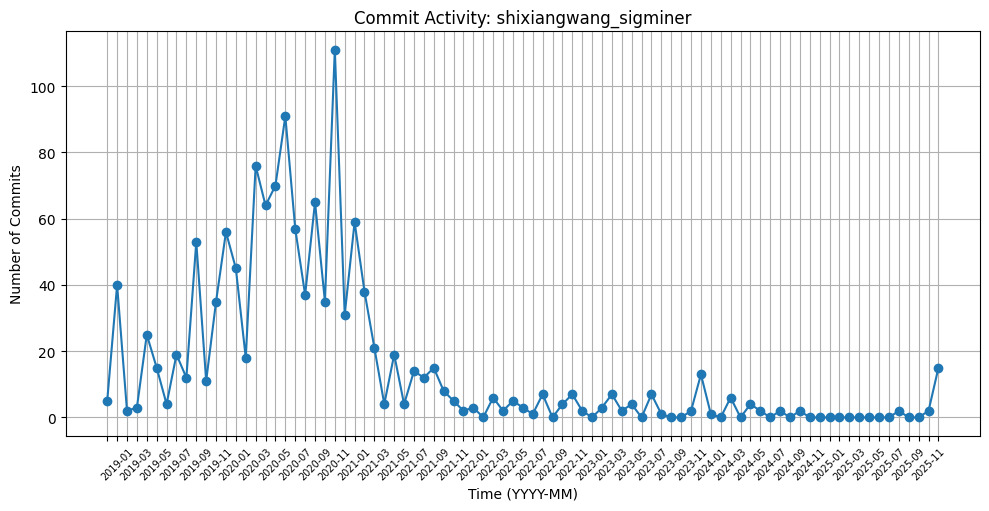

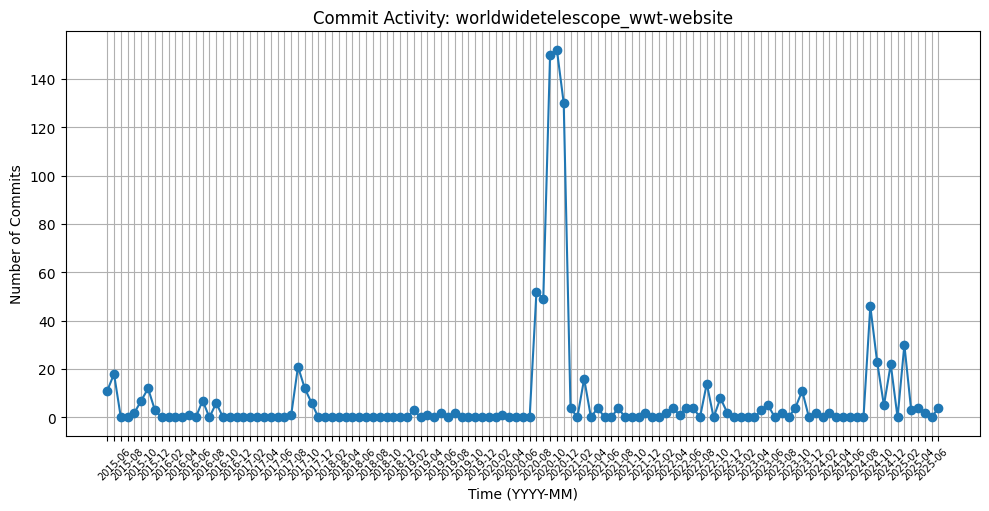

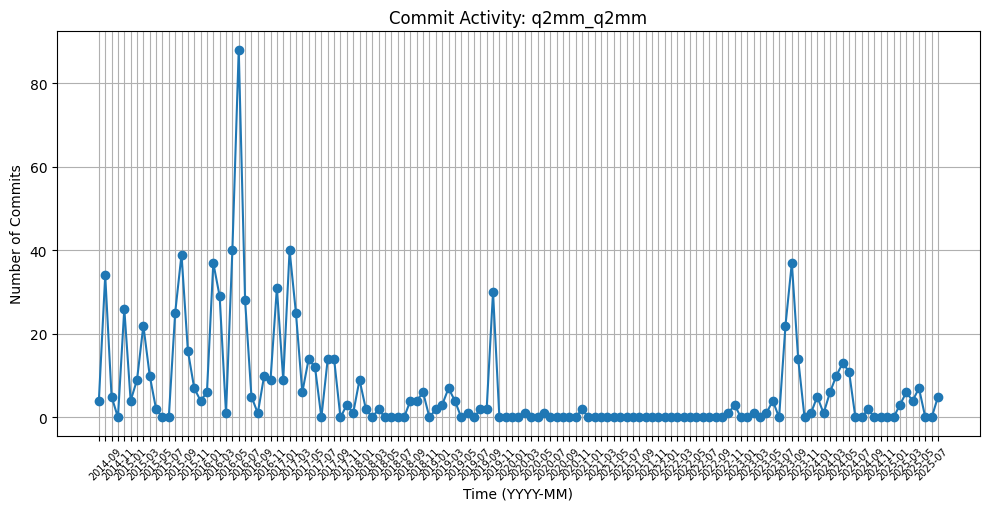

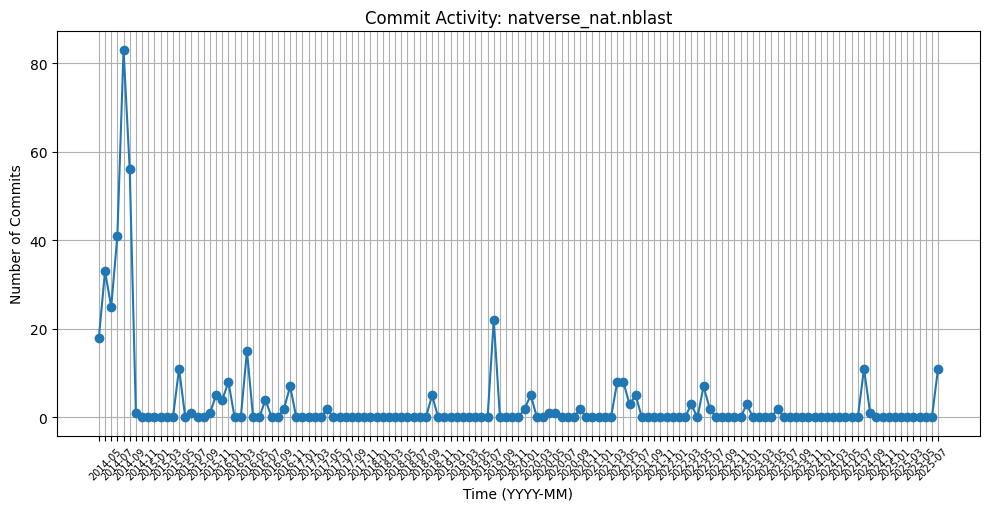

In [24]:
import matplotlib.ticker as ticker
projects = ['vida-nyu_reprozip', 'llnl_mgmol', 'scifio_scifio-imageio', 'smistad_fast', 
            'mouseland_kilosort', 'martini-alessandro_maximum-entropy-spectrum', 'shixiangwang_sigminer',
             'worldwidetelescope_wwt-website', 'q2mm_q2mm', 'natverse_nat.nblast']

for prj in projects:
    df1 = df[df['project']==prj]
    df2 = df1.groupby('Month').size().reset_index(name='Commits')
    #print(df2.head())
    #print(df2.info())
    monthly_counts = df2
    monthly_counts['time'] = pd.to_datetime(monthly_counts['Month'])
    full_date_range = pd.DataFrame({'time': pd.date_range(start=monthly_counts['time'].min(), end=monthly_counts['time'].max(), freq='MS')})
    monthly_counts = pd.merge(full_date_range, monthly_counts, on='time', how='left').fillna(0)
    monthly_counts['Month'] = monthly_counts['time'].dt.strftime('%Y-%m')
    
    # Plot
    plt.figure(figsize=(10,5))
    plt.plot(monthly_counts["Month"], monthly_counts["Commits"], marker="o", linestyle="-")
    plt.xlabel("Time (YYYY-MM)")
    plt.ylabel("Number of Commits")
    plt.title("Commit Activity: "+prj)
    plt.grid(True)
    plt.tight_layout()
    ax =  plt.gca()
    for label in ax.xaxis.get_ticklabels()[::2]:
        label.set_visible(False)
    plt.xticks(rotation=45, fontsize=7)
    plt.savefig("ggood3_timeseries_"+prj+".png", dpi=600)
    plt.show()
    plt.close()


# Identify the Longest Inactivity Gap




# Interpretation.

I examined the commit histories for long-term trends, recurring patterns, and irregular changes. A gap is defined as at least three consecutive calendar months with no commits. The counts below describe gaps between recorded activity in the supplied dataset; they do not include an unfinished period of inactivity after the last recorded commit.

vida-nyu_reprozip — Declining; 3 gaps. Activity was highest early in the project and generally decreased over time. Occasional increases, such as in 2021, interrupt the decline but do not reverse the overall pattern.

llnl_mgmol — U-shaped; 2 gaps. Activity increased through 2020, fell sharply in 2021–2022, and recovered in 2023–2025. This decrease followed by renewed development supports the U-shaped classification.

scifio_scifio-imageio — Irregular; 14 gaps. Commits occur in uneven bursts separated by frequent inactive periods. The timing of these bursts does not show a clear recurring cycle, and activity does not consistently increase or decrease.

smistad_fast — Declining overall, with a recent rebound; 1 gap. Activity generally decreased toward 2024, although the recorded 2025 activity increased substantially. The declining label therefore describes the earlier long-term movement rather than a continuous decrease throughout the entire history.

mouseland_kilosort — Rising during the recovery period; 2 gaps. Activity decreased through 2022 before increasing considerably in 2023–2024. The rising classification best describes this recovery period, since the full history includes both decreases and increases.

martini-alessandro_maximum-entropy-spectrum — Irregular; 3 gaps. Activity is concentrated in a large burst during 2021, followed by much lower activity and another smaller increase in 2023. These uneven changes suggest intermittent work rather than a steady trend or predictable cycle.

shixiangwang_sigminer — Declining; 1 gap. Activity peaked in 2020 and decreased sharply afterward. Later commits show continued maintenance, but activity remains much lower than during the main development period.

worldwidetelescope_wwt-website — Irregular; 8 gaps. Activity varies considerably, with a particularly large burst in 2020 and a smaller increase in 2024. These isolated increases and repeated gaps do not form a consistent upward, downward, or seasonal pattern.

q2mm_q2mm — U-shaped, with a partial recovery; 5 gaps. Higher early activity was followed by a substantial slowdown and a prolonged gap. Development resumed in late 2022 and increased in 2023, although the recovery did not return to the early peak.

natverse_nat.nblast — Declining; 12 gaps. Most activity occurred near the beginning of the project, followed by much lower levels of intermittent development and maintenance. Frequent gaps reinforce the pattern of reduced activity over time.


In [26]:
from pathlib import Path

# GitHub repository metadata checked on 2026-10-07.
github_info = {
    'vida-nyu_reprozip': {'stars': 363, 'forks': 37, 'last_commit': '2026-01-18'},
    'llnl_mgmol': {'stars': 47, 'forks': 15, 'last_commit': '2026-09-11'},
    'scifio_scifio-imageio': {'stars': 16, 'forks': 14, 'last_commit': '2026-04-22'},
    'smistad_fast': {'stars': 517, 'forks': 113, 'last_commit': '2026-10-07'},
    'mouseland_kilosort': {'stars': 631, 'forks': 296, 'last_commit': '2026-09-25'},
    'martini-alessandro_maximum-entropy-spectrum': {'stars': 48, 'forks': 11, 'last_commit': '2024-11-18'},
    'shixiangwang_sigminer': {'stars': 163, 'forks': 20, 'last_commit': '2026-09-27'},
    'worldwidetelescope_wwt-website': {'stars': 44, 'forks': 18, 'last_commit': '2026-06-10'},
    'q2mm_q2mm': {'stars': 25, 'forks': 9, 'last_commit': '2026-04-20'},
    'natverse_nat.nblast': {'stars': 18, 'forks': 7, 'last_commit': '2026-08-24'},
}
activity_patterns = {
    'vida-nyu_reprozip': 'declining',
    'llnl_mgmol': 'U-shaped',
    'scifio_scifio-imageio': 'irregular',
    'smistad_fast': 'declining',
    'mouseland_kilosort': 'rising',
    'martini-alessandro_maximum-entropy-spectrum': 'irregular',
    'shixiangwang_sigminer': 'declining',
    'worldwidetelescope_wwt-website': 'irregular',
    'q2mm_q2mm': 'U-shaped',
    'natverse_nat.nblast': 'declining',
}

stats_source = pd.read_csv('ggood3_project_summary.csv', sep=';')
stats_source.columns = ['project', 'commit', 'author', 'time', 'message']
stats_source['month'] = pd.to_datetime(stats_source['time'], unit='s').dt.to_period('M')

stats_rows = []
for project in projects:
    project_commits = stats_source[stats_source['project'] == project].copy()
    monthly = project_commits.groupby('month').size()
    full_months = pd.period_range(monthly.index.min(), monthly.index.max(), freq='M')
    monthly = monthly.reindex(full_months, fill_value=0)

    zero_runs = []
    gap_start = None
    for month, count in monthly.items():
        if count == 0 and gap_start is None:
            gap_start = month
        elif count > 0 and gap_start is not None:
            zero_runs.append((gap_start, month - 1))
            gap_start = None

    gaps_of_three_months = [
        (start, end) for start, end in zero_runs
        if (end - start).n + 1 >= 3
    ]
    longest_gap = max(
        zero_runs,
        key=lambda gap: (gap[1] - gap[0]).n + 1,
        default=None,
    )

    if longest_gap is None:
        longest_start, longest_end, longest_length = 'N/A', 'N/A', 0
        commits_after_gap = 0
    else:
        longest_start, longest_end = map(str, longest_gap)
        longest_length = (longest_gap[1] - longest_gap[0]).n + 1
        commits_after_gap = int(
            project_commits[project_commits['month'] > longest_gap[1]].shape[0]
        )

    metadata = github_info[project]
    stats_rows.append({
        'project': project,
        'number of commits': len(project_commits),
        'number of authors': project_commits['author'].nunique(),
        'max time': int(project_commits['time'].max()),
        'min time': int(project_commits['time'].min()),
        'number of stars': metadata['stars'],
        'number of forks': metadata['forks'],
        'last commit date': metadata['last_commit'],
        'LongestGapStart (YYYY-MM)': longest_start,
        'LongestGapEnd (YYYY-MM)': longest_end,
        'LongestGapLength (months)': longest_length,
        'NumCommitsAfterLastGap': commits_after_gap,
        'NumberOfGapsInTimeline': len(gaps_of_three_months),
        'ActivityPattern': activity_patterns[project],
    })

project_stats = pd.DataFrame(stats_rows)
project_stats.to_csv('ggood3_project_stats.csv', sep=';', index=False)
project_stats

,project,number of commits,number of authors,max time,min time,number of stars,number of forks,last commit date,LongestGapStart (YYYY-MM),LongestGapEnd (YYYY-MM),LongestGapLength (months),NumCommitsAfterLastGap,NumberOfGapsInTimeline,ActivityPattern
0,vida-nyu_reprozip,3243,45,1770178021,1399066892,363,37,2026-01-18,2025-02,2025-11,10,9,3,declining
1,llnl_mgmol,1692,21,1762220537,1499309382,47,15,2026-09-11,2022-03,2023-01,11,659,2,U-shaped
2,scifio_scifio-imageio,322,31,1751030893,1300299218,16,14,2026-04-22,2022-06,2024-05,24,22,14,irregular
3,smistad_fast,4450,34,1762441025,1395226931,517,113,2026-10-07,2024-05,2024-07,3,445,1,declining
4,mouseland_kilosort,1822,72,1762295880,1525436949,631,296,2026-09-25,2022-04,2022-10,7,984,2,rising
5,martini-alessandro_maximum-entropy-spectrum,405,9,1731950479,1607546094,48,11,2024-11-18,2021-08,2021-12,5,99,3,irregular
6,shixiangwang_sigminer,1296,16,1766677571,1546075731,163,20,2026-09-27,2024-11,2025-07,9,19,1,declining
7,worldwidetelescope_wwt-website,886,21,1753882187,1430448399,44,18,2026-06-10,2017-12,2019-01,14,779,8,irregular
8,q2mm_q2mm,869,27,1754426224,1409012536,25,9,2026-04-20,2021-01,2022-10,22,157,5,U-shaped
9,natverse_nat.nblast,419,8,1755516779,1396549161,18,7,2026-08-24,2017-06,2018-09,16,102,12,declining
